In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [50]:
flights = pd.read_csv('C:/Users/kloum/Documents/Big Blue Data/githubproj/team2/csv/flight_delays.csv', encoding = "utf-8")

In [4]:
flights.head()

,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


In [5]:
flights.describe().apply(lambda s: s.apply('{0:.5f}'.format))

,FlightID,FlightNumber,DelayMinutes,Distance
count,1747627.00000,1747627.00000,1747627.00000,1747627.00000
mean,873814.00000,5001.15753,9.99918,1549.93614
std,504496.60378,2885.82239,11.83112,836.86814
min,1.00000,1.00000,-10.00000,100.00000
25%,436907.50000,2503.00000,0.00000,825.00000
50%,873814.00000,5002.00000,10.00000,1551.00000
75%,1310720.50000,7499.00000,20.00000,2274.00000
max,1747627.00000,9999.00000,30.00000,3000.00000


In [6]:
flights.info(verbose=True, null_counts=True)

C:\Users\kloum\AppData\Local\Temp\ipykernel_27560\3070457106.py:1: FutureWarning: null_counts is deprecated. Use show_counts instead
  flights.info(verbose=True, null_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   FlightID            1747627 non-null  int64 
 1   Airline             1747627 non-null  object
 2   FlightNumber        1747627 non-null  int64 
 3   Origin              1747627 non-null  object
 4   Destination         1747627 non-null  object
 5   ScheduledDeparture  1747627 non-null  object
 6   ActualDeparture     1747627 non-null  object
 7   ScheduledArrival    1747627 non-null  object
 8   ActualArrival       1747627 non-null  object
 9   DelayMinutes        1747627 non-null  int64 
 10  DelayReason         1278754 non-null  object
 11  Cancelled           1747627 non-null  bool  
 12  Diverted            1747627 non-null  bool  
 13  AircraftType        1747627 non-null  object
 14  TailNumber          1747627 non-null  object
 15  Distance            1747627 non-

In [7]:
flights.duplicated().sum()

0

In [8]:
flights['ScheduledDeparture'] = pd.to_datetime(flights['ScheduledDeparture'])
flights['ActualDeparture'] = pd.to_datetime(flights['ActualDeparture'])
flights['ScheduledArrival'] = pd.to_datetime(flights['ScheduledArrival'])
flights['ActualArrival'] = pd.to_datetime(flights['ActualArrival'])

In [9]:
flights.info(verbose=True, null_counts=True)

C:\Users\kloum\AppData\Local\Temp\ipykernel_27560\3070457106.py:1: FutureWarning: null_counts is deprecated. Use show_counts instead
  flights.info(verbose=True, null_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   FlightID            1747627 non-null  int64         
 1   Airline             1747627 non-null  object        
 2   FlightNumber        1747627 non-null  int64         
 3   Origin              1747627 non-null  object        
 4   Destination         1747627 non-null  object        
 5   ScheduledDeparture  1747627 non-null  datetime64[ns]
 6   ActualDeparture     1747627 non-null  datetime64[ns]
 7   ScheduledArrival    1747627 non-null  datetime64[ns]
 8   ActualArrival       1747627 non-null  datetime64[ns]
 9   DelayMinutes        1747627 non-null  int64         
 10  DelayReason         1278754 non-null  object        
 11  Cancelled           1747627 non-null  bool          
 12  Diverted            1747627 non-null  bool          
 13  AircraftType

In [10]:
flights["DepartureDiff"]= flights['ScheduledDeparture'] - flights['ActualDeparture']
flights['DepartureDiff'] = flights['DepartureDiff'] / pd.Timedelta(minutes=1)
flights['DepartureDiff'] = flights['DepartureDiff'].astype(int)

<Axes: title={'center': 'Dealy Minutes'}>

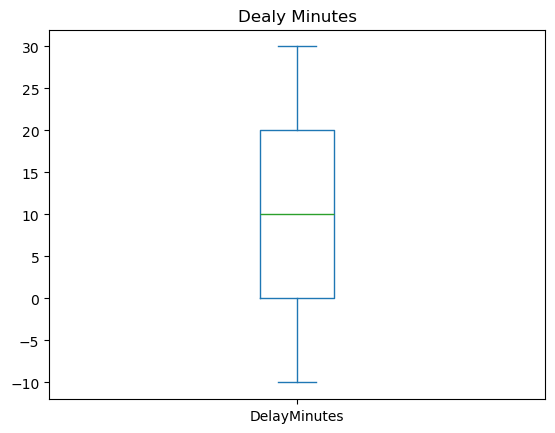

In [22]:
flights['DelayMinutes'].plot(kind='box', title='Dealy Minutes')

In [48]:
flights['ScheduledDeparture'].plot(kind='box', title='Scheduled Departure')

TypeError: no numeric data to plot

<Axes: title={'center': 'Distance'}>

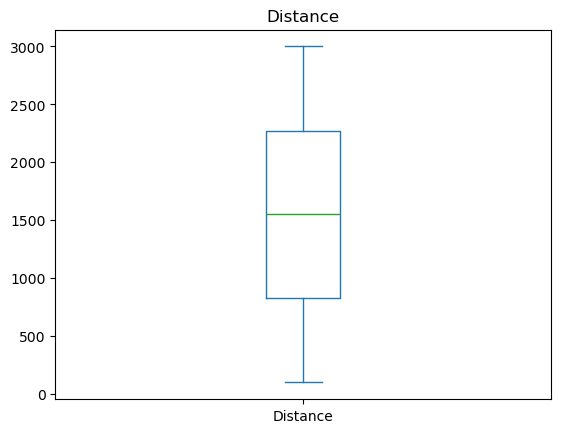

In [47]:
flights['Distance'].plot(kind='box', title='Distance')

In [68]:
max_value = flights['DelayMinutes'].max()
flights[flights['DelayMinutes'] == max_value].count()

FlightID              42456
Airline               42456
FlightNumber          42456
Origin                42456
Destination           42456
ScheduledDeparture    42456
ActualDeparture       42456
ScheduledArrival      42456
ActualArrival         42456
DelayMinutes          42456
DelayReason           42456
Cancelled             42456
Diverted              42456
AircraftType          42456
TailNumber            42456
Distance              42456
dtype: int64

In [70]:
print(max_value)

30


In [72]:
negative = flights[flights['DelayMinutes'] < 0]

In [78]:
max_value_negative = negative['DelayMinutes'].abs().max()
negative[negative['DelayMinutes'].abs() == max_value_negative].count()

FlightID              42583
Airline               42583
FlightNumber          42583
Origin                42583
Destination           42583
ScheduledDeparture    42583
ActualDeparture       42583
ScheduledArrival      42583
ActualArrival         42583
DelayMinutes          42583
DelayReason               0
Cancelled             42583
Diverted              42583
AircraftType          42583
TailNumber            42583
Distance              42583
dtype: int64

In [77]:
negative['DelayMinutes'].abs().max()

10

In [39]:
airlines = flights.groupby('Airline')['DelayMinutes'].mean()

In [42]:
print(airlines)

Airline
American Airlines     9.986951
Delta                 9.998505
Southwest            10.008476
United               10.002781
Name: DelayMinutes, dtype: float64


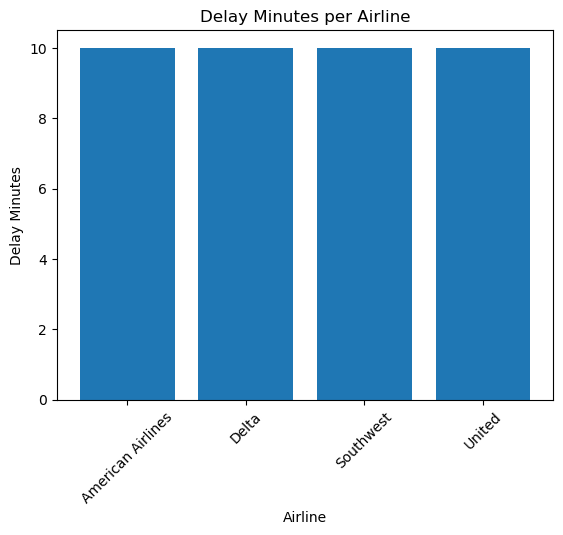

In [41]:
plt.bar(airlines.index, airlines.values)
plt.xlabel("Airline")
plt.ylabel("Delay Minutes")
plt.title("Delay Minutes per Airline")
plt.xticks(rotation=45)  # optional, helps long names show clearly
plt.show()

In [43]:
distance = flights.groupby('Airline')['Distance'].mean() 

In [44]:
print(distance)

Airline
American Airlines    1550.531872
Delta                1548.654097
Southwest            1549.651376
United               1550.908576
Name: Distance, dtype: float64


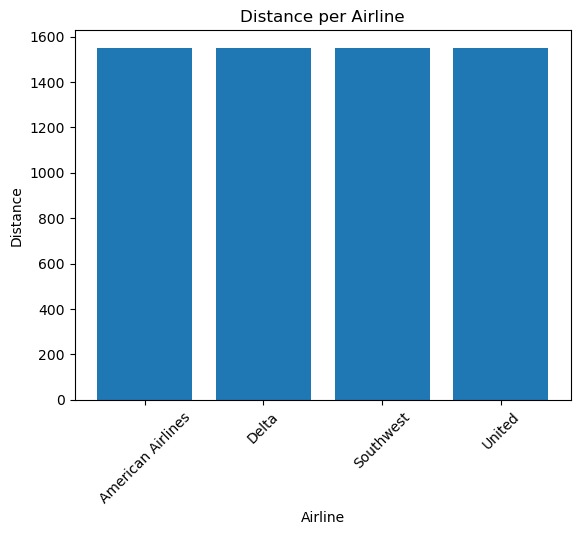

In [51]:
plt.bar(distance.index, distance.values)
plt.xlabel("Airline")
plt.ylabel("Distance")
plt.title("Distance per Airline")
plt.xticks(rotation=45)  # optional, helps long names show clearly
plt.show()

In [81]:
flights['DelayMinutes'].unique()

array([  8,   2,  14, -10,  24,  -5,   7,  25,  -6,  30,   3,  13,  26,
        -9,  17,  16,  29,  21,  23,   4,  10,  28,  12,  18,  27,   9,
        -2,  19,   0,  -1,  -7,  22,  -3,  15,  20,   5,   1,  -8,   6,
        11,  -4], dtype=int64)

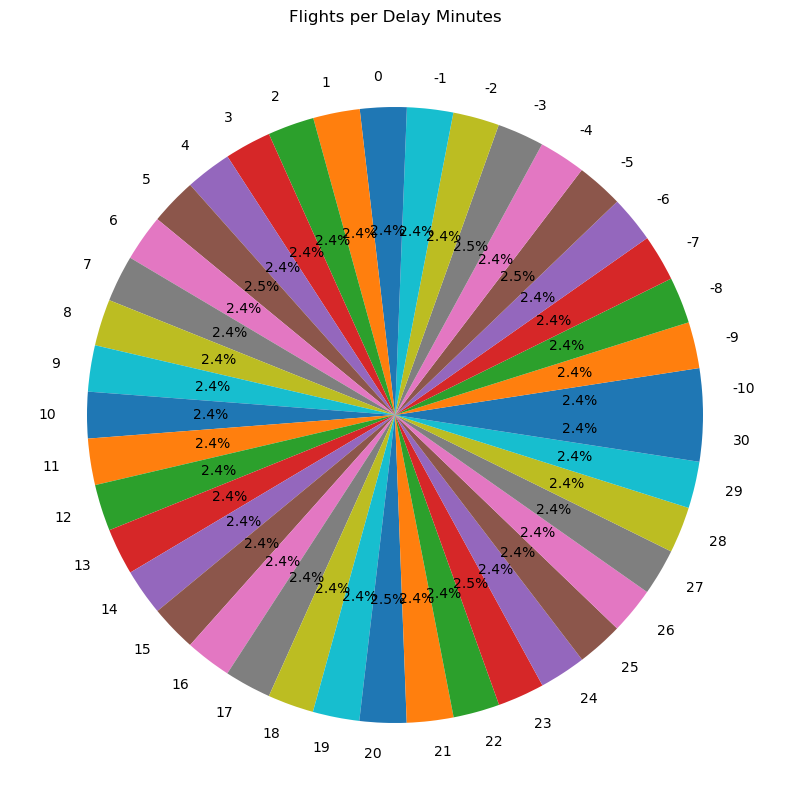

In [91]:
delay_counts = flights.groupby('DelayMinutes')['FlightID'].count()
plt.figure(figsize=(10,10))
plt.pie(delay_counts.values, labels=delay_counts.index, autopct="%1.1f%%")
plt.title("Flights per Delay Minutes")
plt.show()